In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_30963/1361973524.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


In [463]:
k_max = 7

pars = {
    "eta" : 0.2, 
    "beta" : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:3] = 1/3
pars["gamma"][0:3] = 1/3


In [464]:
pars["beta"]

array([0.33333333, 0.33333333, 0.33333333, 0.        , 0.        ,
       0.        , 0.        ])

A components
sparsity = 0.6327, nan = 0.0000
sparsity = 0.9130, nan = 0.0000
sparsity = 0.7347, nan = 0.0000
A
sparsity = 0.9036, nan = 0.0000
B
sparsity = 0.7522, nan = 0.0000


[Text(0.5, 1.0, 'Sparsity: 0.977')]

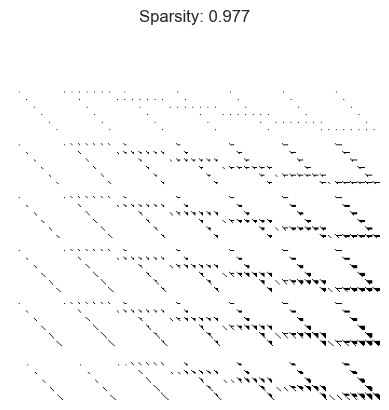

In [465]:
MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

In [466]:
EV = np.linalg.eig(M)

In [467]:
v = np.abs(EV[1][:,0])
T = m.vec_to_tensor(v, k_max)

q = T.sum(axis = (0, 1))
q = q / q.sum()

q

array([5.16852477e-18, 1.00000000e+00, 2.38996489e-16, 1.82358058e-17,
       5.82832003e-20, 1.76461053e-37, 0.00000000e+00])

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_30963/3149062302.py:12: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(T[:,:,k]))


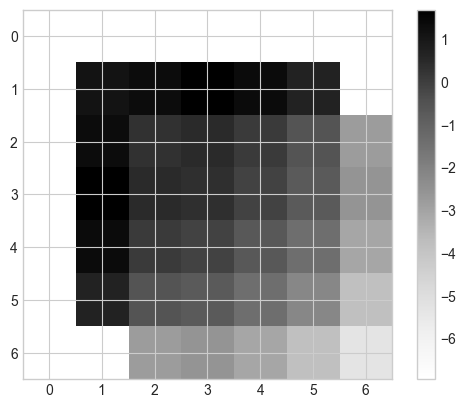

In [472]:
# should be able to get slices of marginal given that intersection of two edges has size k. 
# NOT NECESSARILY SYMMETRIC DUE TO METHOD OF DERIVATION
# we can symmetrize by modifying the derivation. 
# simply adding the array to its transpose should give correct marginals etc. 
# Should have r_{ijk} = 0 when k > i or k > j. 
# We should also have nonzero mass on r_{ij0} for all i, j. 

# experimental symmetrization
T = T + np.transpose(T, (1, 0, 2))

k = 1
plt.imshow(np.log(T[:,:,k]))
plt.colorbar() 
# plt.gca().axis("off")

In [469]:
T.sum(axis=(0, 1))

array([2.99161751e-17, 5.78814584e+00, 1.38334653e-15, 1.05551503e-16,
       3.37351663e-19, 1.02138231e-36, 0.00000000e+00])

This looks like a pretty implausible intersection pattern; for example, it suggests that edges of size 4 never have an intersection of size 2. 

In [431]:
sum(1 for i in range(0))

0

Various probable issues here but progress is being made. 